В этом блокноте будет решение ДЗ1 по теме диффузия, дисциплина "PINN". Оригинальный пример Diffusion equation без усложнений.

Compiling model...
Building feed-forward neural network...
'build' took 0.159603 s

'compile' took 1.785545 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [1.64e+01, 7.71e-02, 7.49e-01]    [1.74e+01, 7.71e-02, 7.49e-01]    [1.31e+00]    
1000      [1.78e-03, 2.14e-03, 5.85e-04]    [3.60e-03, 2.14e-03, 5.85e-04]    [5.76e-02]    
2000      [3.15e-04, 3.73e-04, 1.71e-04]    [6.09e-04, 3.73e-04, 1.71e-04]    [2.46e-02]    
3000      [1.10e-04, 2.54e-05, 1.97e-05]    [3.16e-04, 2.54e-05, 1.97e-05]    [6.34e-03]    
4000      [5.97e-05, 3.21e-06, 4.78e-06]    [2.56e-04, 3.21e-06, 4.78e-06]    [2.33e-03]    
5000      [1.23e-04, 5.23e-06, 3.32e-06]    [2.46e-04, 5.23e-06, 3.32e-06]    [2.54e-03]    
6000      [5.41e-05, 2.69e-06, 3.04e-06]    [2.27e-04, 2.69e-06, 3.04e-06]    [2.20e-03]    
7000      [4.42e-05, 3.19e-06, 1.57e-06]    [1.84e-04, 3.19e-06, 1.57e-06]    [2.19e-03]    
8000      [8.55e-05, 4.87e-06, 1.

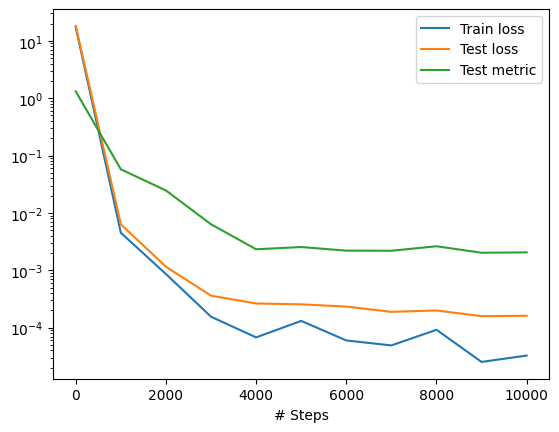

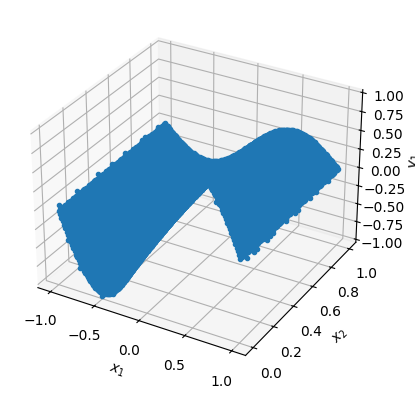

In [ ]:
!pip install deepxde
import deepxde as dde
import numpy as np
# Backend tensorflow.compat.v1 or tensorflow
from deepxde.backend import tf

def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, j=1)
    dy_xx = dde.grad.hessian(y, x, j=0)

    # Backend tensorflow.compat.v1 or tensorflow
    return (
        dy_t
        - dy_xx
        + tf.exp(-x[:, 1:])
        * (tf.sin(np.pi * x[:, 0:1]) - np.pi ** 2 * tf.sin(np.pi * x[:, 0:1]))
    )

def func(x):
    return np.sin(np.pi * x[:, 0:1]) * np.exp(-x[:, 1:])


geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, func, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(geomtime, func, lambda _, on_initial: on_initial)
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=40,
    num_boundary=20,
    num_initial=10,
    solution=func,
    num_test=10000,
)

layer_size = [2] + [32] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)

model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

Compiling model...
Building feed-forward neural network...
'build' took 0.210467 s

'compile' took 2.773359 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [4.94e-03, 2.07e-12, 7.69e+00, 6.47e-01]    [3.02e-04, 2.07e-12, 7.69e+00, 6.47e-01]    [1.39e+00]    
1000      [4.66e-03, 5.84e-07, 7.54e+00, 6.04e-01]    [2.87e-04, 5.84e-07, 7.54e+00, 6.04e-01]    [1.37e+00]    
2000      [4.39e-03, 2.25e-06, 7.39e+00, 5.62e-01]    [2.72e-04, 2.25e-06, 7.39e+00, 5.62e-01]    [1.36e+00]    
3000      [4.13e-03, 4.82e-06, 7.24e+00, 5.22e-01]    [2.58e-04, 4.82e-06, 7.24e+00, 5.22e-01]    [1.35e+00]    
4000      [3.87e-03, 8.02e-06, 7.09e+00, 4.83e-01]    [2.44e-04, 8.02e-06, 7.09e+00, 4.83e-01]    [1.33e+00]    
5000      [3.63e-03, 1.18e-05, 6.94e+00, 4.46e-01]    [2.30e-04, 1.18e-05, 6.94e+00, 4.46e-01]    [1.32e+00]    
6000      [3.39e-03, 1.60e-05, 6.79e+00, 4.10e-01]    [2.17e-04, 1.60e-05, 6.79

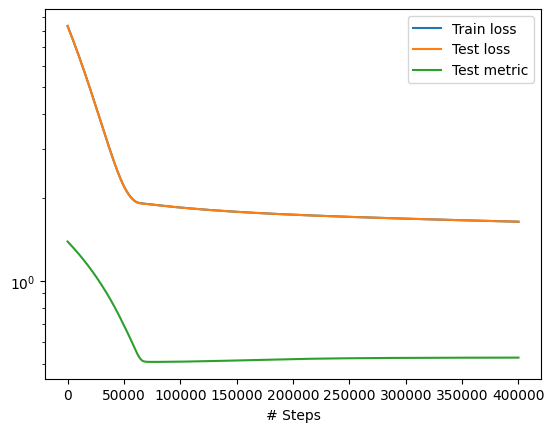

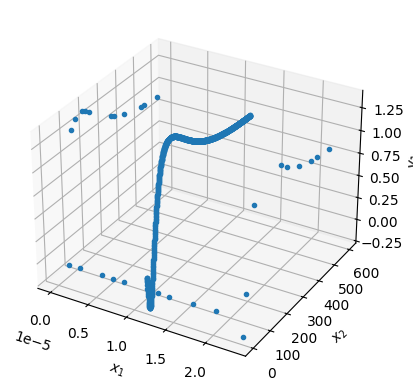

In [ ]:
#Расчёт по формулам из учебника Данилиной (ЗАГОНКА)

!pip install deepxde
import deepxde as dde
import numpy as np
from deepxde.backend import tf
from math import sqrt, pi

D1 = 2.5e-14 #см^2/c, коэффициент диффузии при загонке в случае диффузии фосфора в кремний с электропроводностью p-типа при температуре T1 = 1050 C и удельным сопротивлением 10 Ом*см
t1 = 10*60 #c - время диффузии (стадии загонка)
C0 = 1.2e21 #см^(-3) - поверхностная концентрация молекул из бескоечного источника (т.к. загонка)
N = 2*C0*((D1*t1)/pi) #см^(-2) - Поверхностная плотность атомов примеси, введенной на стадии загонки
xj_1 = 6*sqrt(D1*t1) #мкм - глубина залегания p-n перехода на стадии загонки по упрощённой формуле
#граничные условия1: N (при (x > 0) и (t = 0)) = 0
#граничные условия2: N (при (x = 0) и (t > 0)) = C0
#граничные условия3: N (при (x = xj) и (t > 0)) = 0
#N1(x,t) = C0*exp(-(x/(2*sqrt(D1*t1)+0.3))^2) - закон распределения профиля диффузии на стадии загонки (решение уравнения)
#dN/dt = D*d^2N/dx^2 - закон распределения диффузии (дифференциальное уравнение)

#ВМЕСТО НОРМАЛИЗАЦИИ
D1 = 1
C0 = 2

def pde(x, N):
    dN_t = dde.grad.jacobian(N, x, j=1)
    dN_xx = dde.grad.hessian(N, x, j=0)
    return dN_t - D1 * dN_xx

def func(x):
    return C0 * np.exp(-((x[:, 0:1]) / (2 * np.sqrt(D1 * t1) + 0.3)) ** 2)

xj = xj_1
geom = dde.geometry.Interval(0, xj)
timedomain = dde.geometry.TimeDomain(0, t1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

def initial_condition(x):
    return np.zeros_like(x[:, 0:1])

ic = dde.icbc.IC(geomtime, initial_condition, lambda _, on_initial: on_initial)

bc_left = dde.icbc.DirichletBC(geomtime, lambda x: C0, lambda x, on_boundary: on_boundary and np.isclose(x[0], 0))

bc_right = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_boundary: on_boundary and np.isclose(x[0], xj))

data = dde.data.TimePDE(
    geomtime,
    pde,
    [ic, bc_left, bc_right],
    num_domain=100,
    num_boundary=20,
    num_initial=10,
    solution=func,
    num_test=1000,
)

layer_size = [2] + [128] * 5 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=1e-8, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=400000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

Compiling model...
Building feed-forward neural network...
'build' took 0.102291 s

'compile' took 1.261100 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [4.89e-03, 3.98e-10, 7.68e+00, 5.96e-01]    [3.12e-06, 3.98e-10, 7.68e+00, 5.96e-01]    [1.15e+00]    
1000      [4.62e-03, 5.27e-07, 7.53e+00, 5.54e-01]    [3.01e-06, 5.27e-07, 7.53e+00, 5.54e-01]    [1.15e+00]    
2000      [4.35e-03, 1.98e-06, 7.38e+00, 5.13e-01]    [2.90e-06, 1.98e-06, 7.38e+00, 5.13e-01]    [1.14e+00]    
3000      [4.09e-03, 4.05e-06, 7.23e+00, 4.74e-01]    [2.80e-06, 4.05e-06, 7.23e+00, 4.74e-01]    [1.13e+00]    
4000      [3.84e-03, 6.38e-06, 7.08e+00, 4.36e-01]    [2.69e-06, 6.38e-06, 7.08e+00, 4.36e-01]    [1.13e+00]    
5000      [3.59e-03, 8.82e-06, 6.93e+00, 4.00e-01]    [2.59e-06, 8.82e-06, 6.93e+00, 4.00e-01]    [1.12e+00]    
6000      [3.36e-03, 1.14e-05, 6.78e+00, 3.65e-01]    [2.48e-06, 1.14e-05, 6.78

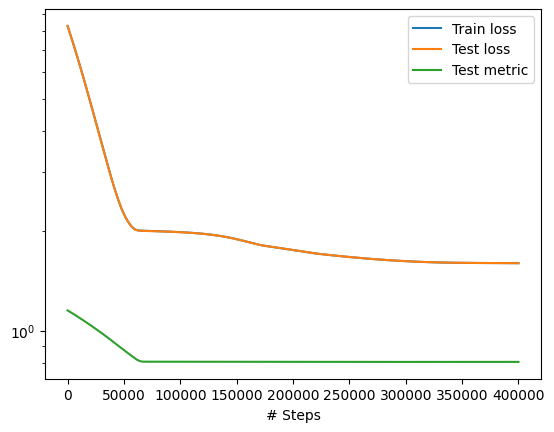

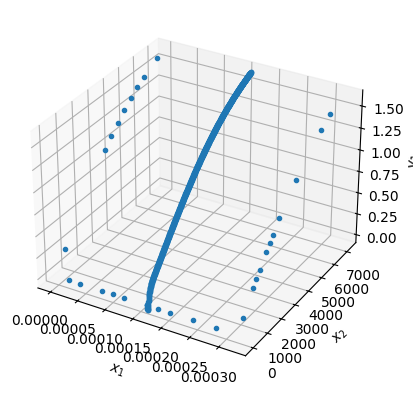

In [ ]:
#Расчёт из учебника Данилиной (РАЗГОНКА)
D2 = 4e-13 #см^2/c
t2 = 2*60*60 #2 часа = 2*60*60 с
N = 2*C0*((D1*t1)/pi) #см^(-2) - Поверхностная плотность атомов примеси, введенной на стадии загонки
xj_2 = 6*sqrt(D2*t2) #мкм - глубина залегания p-n перехода на стадии разгонки по упрощённой формуле
#граничное условие1: N(при (t = 0) и (x = 0)) = C0
#граничное условие2: N(при (t = >0) и (x = xj_2)) = 0
#N2(x,t) = N/(sqrt(pi*D2*t2))*exp(-x^2/(4*D2*t2)) - закон распределения профиля диффузии на стадии загонки (решение уравнения)
#dN/dt = D*d^2N/dx^2 - закон распределения диффузии (дифференциальное уравнение)

#ВМЕСТО НОРМАЛИЗАЦИИ
D2 = 1

def pde(x, N_):
    dN_t = dde.grad.jacobian(N_, x, j=1)
    dN_xx = dde.grad.hessian(N_, x, j=0)
    return dN_t - D2 * dN_xx

def func(x):
    return N / np.sqrt(pi * D2 * t2) * np.exp(-x[:, 0:1] ** 2 / (4 * D2 * t2))

geom = dde.geometry.Interval(0, xj_2)
timedomain = dde.geometry.TimeDomain(0, t2)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)


def initial_condition(x):
    return np.zeros_like(x[:, 0:1])

ic = dde.icbc.IC(geomtime, initial_condition, lambda _, on_initial: on_initial)

bc_left = dde.icbc.DirichletBC(geomtime, lambda x: C0, lambda x, on_boundary: on_boundary and np.isclose(x[0], 0))

bc_right = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_boundary: on_boundary and np.isclose(x[0], xj_2))

data = dde.data.TimePDE(
    geomtime,
    pde,
    [ic, bc_left, bc_right],
    num_domain=100,
    num_boundary=20,
    num_initial=10,
    solution=func,
    num_test=1000,
)

layer_size = [2] + [128] * 5 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=1e-8, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=400000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

Compiling model...
Building feed-forward neural network...
'build' took 0.231290 s

'compile' took 2.774662 s

Training model...

0         [6.32e-02, 7.15e-04, 1.02e+00, 3.81e-03]    [6.32e-02, 7.15e-04, 1.02e+00, 3.81e-03]    [1.04e+00]    
1000      [5.93e-02, 6.73e-04, 1.02e+00, 3.65e-03]    [5.93e-02, 6.73e-04, 1.02e+00, 3.65e-03]    [1.04e+00]    
2000      [5.55e-02, 6.32e-04, 1.02e+00, 3.50e-03]    [5.55e-02, 6.32e-04, 1.02e+00, 3.50e-03]    [1.04e+00]    
3000      [5.18e-02, 5.93e-04, 1.01e+00, 3.35e-03]    [5.18e-02, 5.93e-04, 1.01e+00, 3.35e-03]    [1.04e+00]    
4000      [4.83e-02, 5.56e-04, 1.01e+00, 3.20e-03]    [4.83e-02, 5.56e-04, 1.01e+00, 3.20e-03]    [1.04e+00]    
5000      [4.49e-02, 5.20e-04, 1.01e+00, 3.05e-03]    [4.49e-02, 5.20e-04, 1.01e+00, 3.05e-03]    [1.03e+00]    
6000      [4.16e-02, 4.86e-04, 1.01e+00, 2.91e-03]    [4.16e-02, 4.86e-04, 1.01e+00, 2.91e-03]    [1.03e+00]    
7000      [3.84e-02, 4.53e-04, 1.01e+00, 2.77e-03]    [3.85e-02, 4.53e-04, 1.01

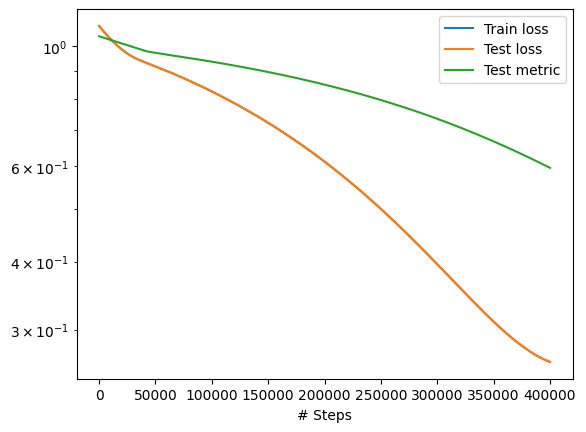

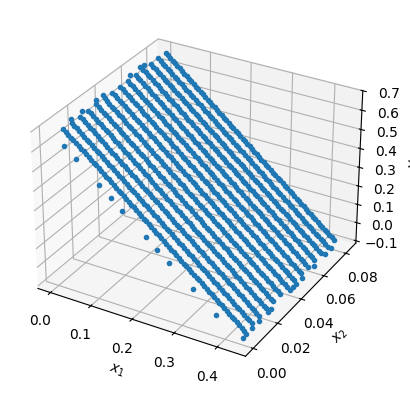

In [ ]:
#ЗАГОНКА С НОРМАЛИЗАЦИЕЙ

#Расчёт по формулам из учебника Данилиной (ЗАГОНКА)

!pip install deepxde
import deepxde as dde
import numpy as np
from deepxde.backend import tf
from math import sqrt, pi

D1 = 2.5e-14 #см^2/c, коэффициент диффузии при загонке в случае диффузии фосфора в кремний с электропроводностью p-типа при температуре T1 = 1050 C и удельным сопротивлением 10 Ом*см
t1 = 10*60 #c - время диффузии (стадии загонка)
C0 = 1.2e21 #см^(-3) - поверхностная концентрация молекул из бескоечного источника (т.к. загонка)
N = 2*C0*((D1*t1)/pi) #см^(-2) - Поверхностная плотность атомов примеси, введенной на стадии загонки
xj_1 = 6*sqrt(D1*t1) #мкм - глубина залегания p-n перехода на стадии загонки по упрощённой формуле
#граничные условия1: N (при (x > 0) и (t = 0)) = 0
#граничные условия2: N (при (x = 0) и (t > 0)) = C0
#граничные условия3: N (при (x = xj) и (t > 0)) = 0
#N1(x,t) = C0*exp(-(x/(2*sqrt(D1*t1)+0.3))^2) - закон распределения профиля диффузии на стадии загонки (решение уравнения)
#dN/dt = D*d^2N/dx^2 - закон распределения диффузии (дифференциальное уравнение)

#Нормализация
t_norm_coef = 2*60*60
d_norm_coef = 4e-13
c0_norm_coef = 1.2e21

t1 = t1/t_norm_coef
C0 = C0/c0_norm_coef
D1 = D1/d_norm_coef
N = 2*C0*((D1*t1)/pi)
xj_1 = 6*sqrt(D1*t1)

def pde(x, N):
    dN_t = dde.grad.jacobian(N, x, j=1)
    dN_xx = dde.grad.hessian(N, x, j=0)
    return dN_t - D1 * dN_xx

def func(x):
    return C0 * np.exp(-((x[:, 0:1]) / (2 * np.sqrt(D1 * t1) + 0.3)) ** 2)

xj = 6 * np.sqrt(D1 * t1)
geom = dde.geometry.Interval(0, xj)
timedomain = dde.geometry.TimeDomain(0, t1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

def initial_condition(x):
    return np.zeros_like(x[:, 0:1])

ic = dde.icbc.IC(geomtime, initial_condition, lambda _, on_initial: on_initial)

bc_left = dde.icbc.DirichletBC(geomtime, lambda x: C0, lambda x, on_boundary: on_boundary and np.isclose(x[0], 0))

bc_right = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_boundary: on_boundary and np.isclose(x[0], xj))

data = dde.data.TimePDE(
    geomtime,
    pde,
    [ic, bc_left, bc_right],
    num_domain=100,
    num_boundary=20,
    num_initial=10,
    solution=func,
    num_test=1000,
)

layer_size = [2] + [128] * 5 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=1e-8, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=400000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

Compiling model...
Building feed-forward neural network...
'build' took 0.196690 s

'compile' took 2.003840 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [9.69e-03, 6.95e-02, 8.49e-01, 1.07e-01]    [8.36e-03, 6.95e-02, 8.49e-01, 1.07e-01]    [2.77e+02]    
1000      [1.09e-02, 5.65e-02, 8.40e-01, 8.58e-02]    [9.54e-03, 5.65e-02, 8.40e-01, 8.58e-02]    [2.46e+02]    
2000      [1.24e-02, 4.52e-02, 8.31e-01, 6.76e-02]    [1.09e-02, 4.52e-02, 8.31e-01, 6.76e-02]    [2.15e+02]    
3000      [1.39e-02, 3.58e-02, 8.22e-01, 5.24e-02]    [1.24e-02, 3.58e-02, 8.22e-01, 5.24e-02]    [1.88e+02]    
4000      [1.57e-02, 2.77e-02, 8.12e-01, 3.94e-02]    [1.40e-02, 2.77e-02, 8.12e-01, 3.94e-02]    [1.62e+02]    
5000      [1.76e-02, 2.09e-02, 8.02e-01, 2.86e-02]    [1.59e-02, 2.09e-02, 8.02e-01, 2.86e-02]    [1.39e+02]    
6000      [1.98e-02, 1.53e-02, 7.92e-01, 1.99e-02]    [1.80e-02, 1.53e-02, 7.92

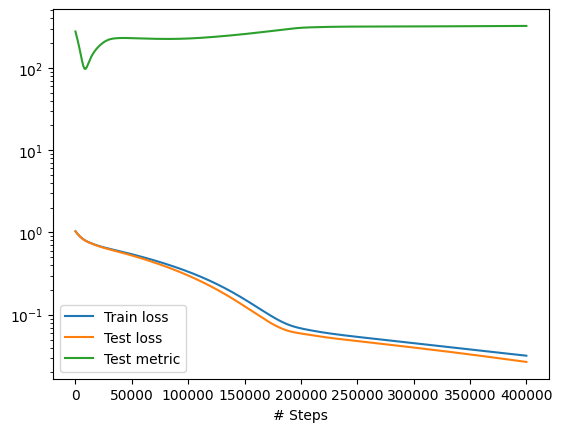

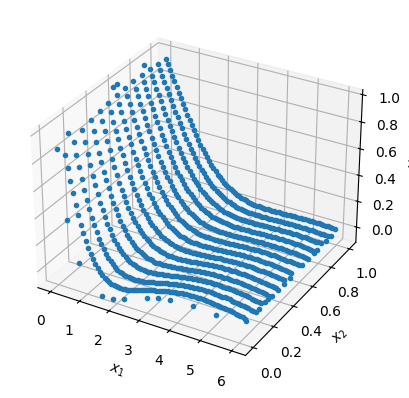

In [ ]:
#РАЗГОНКА С НОРМАЛИЗАЦИЕЙ
D2 = 4e-13 #см^2/c
t2 = 2*60*60 #2 часа = 2*60*60 с
N = 2*C0*((D1*t1)/pi) #см^(-2) - Поверхностная плотность атомов примеси, введенной на стадии загонки
xj_2 = 6*sqrt(D2*t2) #мкм - глубина залегания p-n перехода на стадии разгонки по упрощённой формуле
#граничное условие1: N(при (t = 0) и (x = 0)) = C0
#граничное условие2: N(при (t = >0) и (x = xj_2)) = 0
#N2(x,t) = N/(sqrt(pi*D2*t2))*exp(-x^2/(4*D2*t2)) - закон распределения профиля диффузии на стадии загонки (решение уравнения)
#dN/dt = D*d^2N/dx^2 - закон распределения диффузии (дифференциальное уравнение)

#Нормализация
t2 = t2/t_norm_coef
D2 = D2/d_norm_coef
xj_2 = 6*sqrt(D2*t2)

def pde(x, N_):
    dN_t = dde.grad.jacobian(N_, x, j=1)
    dN_xx = dde.grad.hessian(N_, x, j=0)
    return dN_t - D2 * dN_xx

def func(x):
    return N / np.sqrt(pi * D2 * t2) * np.exp(-x[:, 0:1] ** 2 / (4 * D2 * t2))

geom = dde.geometry.Interval(0, xj_2)
timedomain = dde.geometry.TimeDomain(0, t2)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

def initial_condition(x):
    return np.zeros_like(x[:, 0:1])

ic = dde.icbc.IC(geomtime, initial_condition, lambda _, on_initial: on_initial)

bc_left = dde.icbc.DirichletBC(geomtime, lambda x: C0, lambda x, on_boundary: on_boundary and np.isclose(x[0], 0))

bc_right = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_boundary: on_boundary and np.isclose(x[0], xj_2))

data = dde.data.TimePDE(
    geomtime,
    pde,
    [ic, bc_left, bc_right],
    num_domain=100,
    num_boundary=20,
    num_initial=10,
    solution=func,
    num_test=1000,
)

layer_size = [2] + [128] * 10 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=1e-8, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=400000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)